# 🚢 Challenge #01: Titanic — From Scratch

**Authors:** Ziko & Yassine  
**Date:**  thursday 05/03/2026
**Time Limit:** 5 hours  
**Timer Started:**  23:45-thursday
**Timer Ended:**  
**Rules:** No scikit-learn for model building. Only NumPy, Pandas, Matplotlib.

## Step 0: Imports & Data Loading

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [126]:
df = pd.read_csv("data/train.csv")
df=df.set_index('PassengerId')

## Step 1: Problem Framing (30 min) ⏱️

**What am I predicting?**  
- It s a "Binary classification" the "Survived" column , based on people infos i have to predict if they will survive or not.
**What metric defines success?**  
- "accuracy" and "F1-Score" because we have an embalenced data (38% vs 62%)
**Business context:**
- "Understanding which passenger characteristics predicted survival" can inform evacuation protocols and safety priorities

## Step 2: EDA (45 min) ⏱️

In [104]:
survived=df[df["Survived"]==1].shape[0]
print(f"Survived: {survived:>9} | pecentage: {survived/891:.3f}")
print(f"Din't Survive:  {891-survived:<4}| pecentage: {(891-survived)/891:.3f}")

print("not too much imbalenced")

Survived:       342 | pecentage: 0.384
Din't Survive:  549 | pecentage: 0.616
not too much imbalenced


In [105]:
# Basic info: shape, dtypes, nulls, target distribution
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [106]:
print(df.shape)
df.describe()

(891, 11)


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [107]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


👨 Male:   ✅ Survived: 109 | ❌ Didn't survive: 468
👩 Female: ✅ Survived: 233 | ❌ Didn't survive: 81
chance of male survival: 0.189
chance of female survival: 0.742


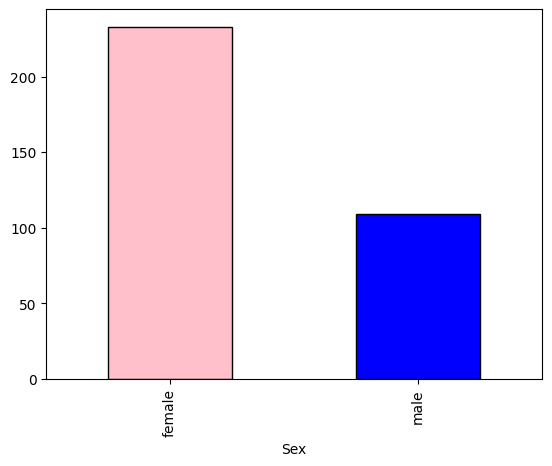

In [108]:
# checking if the "gender" has an effect on survival chances !

Male_survived=df[(df['Survived']==1)&(df['Sex']=='male')].shape[0]
Male_didnt_survived=df[(df['Survived']==0)&(df['Sex']=='male')].shape[0]
Female_survived=df[(df['Survived']==1)&(df['Sex']=='female')].shape[0]
Female_didnt_survived=df[(df['Survived']==0)&(df['Sex']=='female')].shape[0]

print(f"👨 Male:   ✅ Survived: {Male_survived} | ❌ Didn't survive: {Male_didnt_survived}")
print(f"👩 Female: ✅ Survived: {Female_survived} | ❌ Didn't survive: {Female_didnt_survived}")
print(f"chance of male survival: {Male_survived/(Male_survived+Male_didnt_survived):.3f}")
print(f"chance of female survival: {Female_survived/(Female_survived+Female_didnt_survived):.3f}")
survived_sex=df[df['Survived']==1]['Sex'].value_counts()
survived_sex.plot(kind='bar',color=['pink','blue'], edgecolor='black')
plt.show()

First class  | Survived: 136 | Didn t survived: 206
Second class | Survived: 87  | Didn t survived: 255
Third class  | Survived: 119 | Didn t survived: 223


<Axes: xlabel='Pclass'>

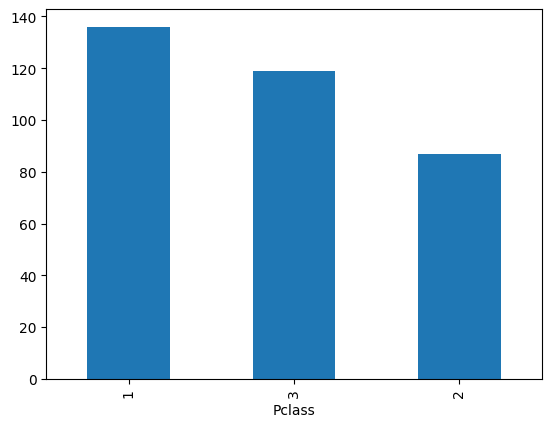

In [109]:
# checking if the "class" has an effect on survival chances !

first_class_survived = df[(df['Survived']==1)&(df['Pclass']==1)].shape[0]
second_class_survived = df[(df['Survived']==1)&(df['Pclass']==2)].shape[0]
third_class_survived = df[(df['Survived']==1)&(df['Pclass']==3)].shape[0]
print(f"First class  | Survived: {first_class_survived} | Didn t survived: {342-first_class_survived}")
print(f"Second class | Survived: {second_class_survived}  | Didn t survived: {342-second_class_survived}")
print(f"Third class  | Survived: {third_class_survived} | Didn t survived: {342-third_class_survived}")

survived_class = df[df['Survived']==1]['Pclass'].value_counts()
survived_class.plot(kind='bar')

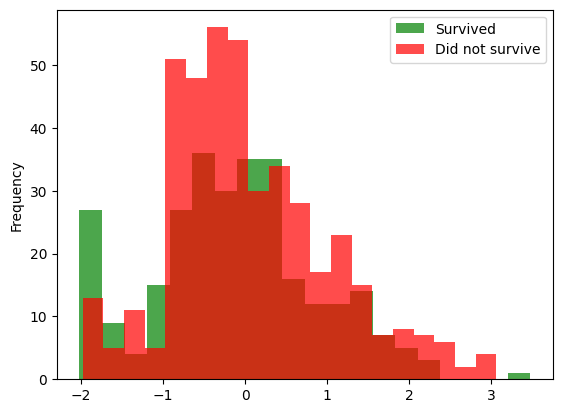

In [142]:
# checking if the age has an effect on survival chances !

df[df['Survived']==1]['Age'].plot(kind='hist', bins=20, alpha=0.7, label='Survived', color='green')
df[df['Survived']==0]['Age'].plot(kind='hist', bins=20, alpha=0.7, label='Did not survive', color='red')
plt.legend()
plt.show()

<Axes: ylabel='Frequency'>

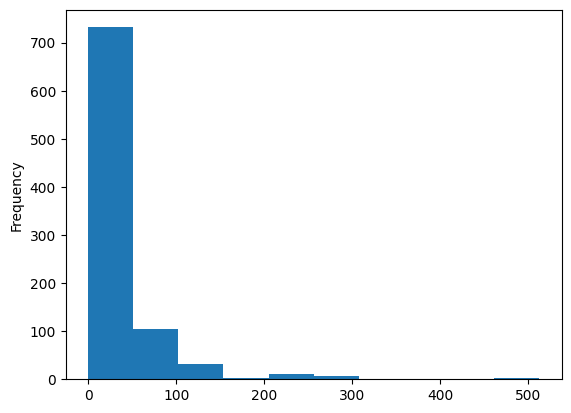

In [124]:
df['Fare'].plot(kind='hist')

In [111]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

### Initial Hypotheses
1. females have more chance to survive
2. higher class means higher chance to survive
3. teenagers and new-born babies have more chance to survive

So a group of people have the chance to escape but they can't all do it.
They choose teens that have more power to survive, along with females (gentlemen haha), and some prefer their babies to inherit from them. And of course, the higher class people with strong 3rd class believers win!

This shit sounds racist hhhhhh

## Step 3: Data Preparation (45 min) ⏱️

In [129]:
# Handle missing values (justify WHY in comments)
df.drop(columns=["Cabin"], inplace=True)
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)
df.dropna(subset=['Embarked'],inplace=True)
# Age : replacing missing values with median (safest option) or maybe we estimate them using KNN or another algo
# Embarked : deleting missiing  values (just 2)
# Cabin : droping column

C:\Users\zikob\AppData\Local\Temp\ipykernel_5360\1843278837.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


In [130]:
df.isnull().sum()

Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           0
Age_category     178
Family             0
Fare_Category      0
dtype: int64

In [137]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family,Fare_Category
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,medium,Braund,low
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,medium,Cumings,medium
3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,medium,Heikkinen,low
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,medium,Futrelle,medium
5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,medium,Allen,low


In [132]:
# Feature Engineering (at least 2 new features, explain reasoning)
# deviding the age into 3 categories 0-20 20-40 40-80
df['Age_category']=pd.cut(df['Age'],
    bins=[0,20,40,80],
    labels=['young','medium','old'],
    right=False)
# separating family name so we can group families
df['Family']=df['Name'].str.split(',').str[0]
# 3 calsses of fare 
df['Fare_Category']=pd.cut(df["Fare"],
                           bins=[0,50,100,float('inf')],
                           labels=['low','medium','high'],
                           right=False)

In [ ]:
# Encoding (justify WHY)
df['Sex']=df['Sex'].replace('male',1)
df['Sex']=df['Sex'].replace('female',0)
# so we can apply algorithms like lineaire regression or something else ,it s now contitative variable

In [138]:
# Train/Validation split (manual, no sklearn)
train_rows = int(df.shape[0]*0.8)
X_train = df.drop('Survived',axis=1).iloc[:train_rows]
Y_train = df['Survived'].iloc[:train_rows]
X_test = df.drop('Survived',axis=1).iloc[train_rows:]
Y_test =df['Survived'][train_rows:] 

In [139]:
# Feature scaling (implement StandardScaler from scratch)
# age and fare
df['Age'] = (df['Age']-df['Age'].mean())/df['Age'].std()

df['Fare'] = (df['Fare']-df['Fare'].mean())/df['Fare'].std()


## Step 4: Models FROM SCRATCH (90 min) ⏱️

### Model 1: Logistic Regression from Scratch

In [ ]:
# Implement LogisticRegression class from scratch
# Hint: sigmoid, binary cross-entropy loss, gradient descent
class LogisticRegression:
    def __init__(self,learning_rate=0.01,n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.w = None
        self.b = None
        self.losses = []
    
    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    
    def fit(self,X,Y):
        X=np.array(X)
        Y=np.array(Y)
        n=len(Y)
        self.w=0
        self.b=0
        for _ in range(self.n_iter):
            y_pred= self.sigmoid(X*self.w+self.b)
            dw = (1/n) * np.sum(X * (y_pred - y))
            db = (1/n) * np.sum(y_pred - y)
            self.w -= self.lr*dw
            self.b -= self.lr*db
        
    def proba(self,X):
        X=np.array(X)
        return self.sigmoid(self.w*X+self.b)
        
    def predict_class(self,X):
        X=np.array(X)
        if self.proba(X)>=0.5 :
            return 1
        else : return 0
        

In [ ]:
# Train and plot loss curve

### Model 2: KNN from Scratch

In [ ]:
# Implement KNN class from scratch
# Hint: euclidean distance, majority vote

In [ ]:
# Train and evaluate

### Model 3: Decision Tree from Scratch

In [ ]:
# Implement DecisionTree class from scratch
# Hint: Gini impurity, recursive splitting

In [ ]:
# Train and evaluate

## Step 5: Evaluation (30 min) ⏱️

In [ ]:
# Implement metrics from scratch: accuracy, precision, recall, F1, confusion matrix

In [ ]:
# Evaluate all 3 models on validation set

In [ ]:
# Visualize: confusion matrices + bar chart comparison

## Step 6: Write-up ⏱️

### Key Findings
1. 
2. 
3. 

### What I'd do with more time
- 

### One thing I learned today
- 

### Where I got stuck
- 

## 🎯 BONUS (if time remains)
- [ ] Add L2 regularization to Logistic Regression
- [ ] Implement k-fold cross-validation from scratch
- [ ] Build Random Forest using your Decision Tree
- [ ] Plot accuracy vs k for KNN
- [ ] Feature importance for Decision Tree